In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.decomposition import PCA, KernelPCA

In [2]:
X, y = make_moons(n_samples=1000, noise=0.01)
X

array([[ 0.84098185,  0.54435127],
       [ 0.00331633,  0.39523284],
       [ 2.00937562,  0.47397569],
       ...,
       [-0.02018711,  0.99417877],
       [ 1.42484948, -0.40387873],
       [ 1.45234929, -0.39535557]], shape=(1000, 2))

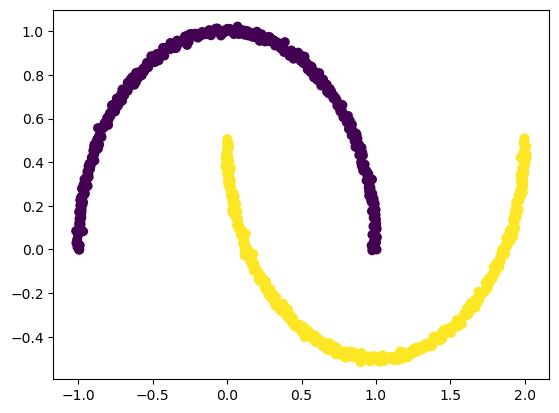

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [4]:
pca = PCA(n_components=1, random_state=42)
pca.fit(X)
pca_result = pca.transform(X)
pca_result

array([[ 2.29420399e-01],
       [-5.16703192e-01],
       [ 1.35906424e+00],
       [ 1.36801598e+00],
       [-5.78132140e-02],
       [ 1.01296295e+00],
       [-8.99804098e-01],
       [ 1.38214369e+00],
       [ 3.13792302e-01],
       [-1.10055192e+00],
       [-1.38121220e+00],
       [-3.48846020e-01],
       [-4.35422731e-02],
       [-3.26722441e-01],
       [-4.47352904e-01],
       [-1.22030403e+00],
       [-1.12590786e+00],
       [-1.39370309e+00],
       [ 5.42850962e-01],
       [ 2.32574772e-01],
       [-2.09887270e-01],
       [ 1.37930932e+00],
       [-1.37310746e+00],
       [ 1.52496385e-01],
       [-1.39649793e+00],
       [ 3.64490206e-02],
       [-1.36051389e+00],
       [ 2.72684677e-01],
       [-8.84171593e-02],
       [ 1.38263020e+00],
       [ 6.69114335e-01],
       [ 1.37795084e+00],
       [ 1.06468866e+00],
       [ 1.40124634e+00],
       [ 5.58001050e-01],
       [-1.36754796e+00],
       [-1.03472900e+00],
       [-5.05017195e-01],
       [ 1.1

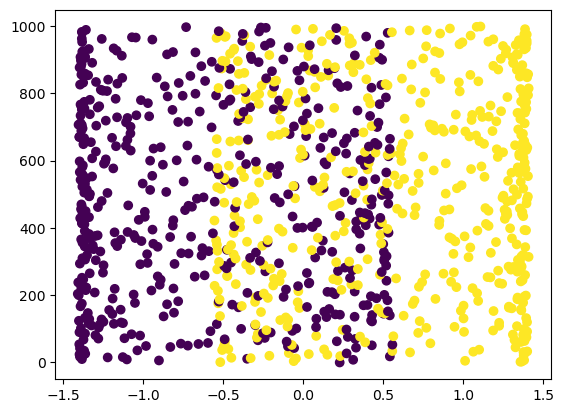

In [6]:
plt.scatter(pca_result[:, 0], range(0, 1000), c=y)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [9]:
rf = RandomForestClassifier(random_state=42)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [13]:
rf.fit(X_train_pca, y_train)
y_predict = rf.predict(X_test_pca)
print(classification_report(y_true=y_test, y_pred=y_predict))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       129
           1       0.75      0.79      0.77       121

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



In [28]:
kpca = KernelPCA(n_components=1, kernel='poly', gamma=10, random_state=42)
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)
X_train_kpca.shape

(750, 1)

In [29]:
rf.fit(X_train_kpca, y_train)
y_predict = rf.predict(X_test_kpca)
print(classification_report(y_true=y_test, y_pred=y_predict))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       129
           1       0.78      0.83      0.80       121

    accuracy                           0.80       250
   macro avg       0.80      0.80      0.80       250
weighted avg       0.80      0.80      0.80       250



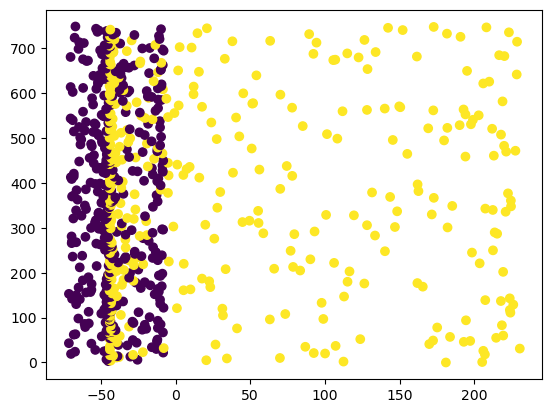

In [33]:
plt.scatter(X_train_kpca[:, 0], range(0, 750), c=y_train)

In [31]:
from sklearn.decomposition import FastICA
from sklearn.manifold import Isomap

In [32]:
ica = FastICA(n_components=1, random_state=42)
X_train_ica = ica.fit_transform(X_train)
X_test_ica = ica.transform(X_test)

In [34]:
rf.fit(X_train_ica, y_train)
y_predict = rf.predict(X_test_ica)
print(classification_report(y_pred=y_predict, y_true=y_test))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       129
           1       0.75      0.79      0.77       121

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



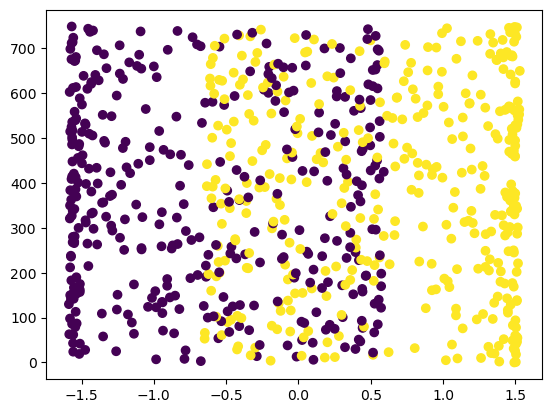

In [35]:
plt.scatter(X_train_ica[:, 0], range(0, 750), c=y_train)

In [36]:
%%time
isomap = Isomap(n_components=1)
X_train_isomap = isomap.fit_transform(X_train)
X_test_isomap = isomap.transform(X_test)

c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 6 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more e

CPU times: total: 1.88 s
Wall time: 238 ms


In [37]:
rf.fit(X_train_isomap, y_train)
y_predict = rf.predict(X_test_isomap)
print(classification_report(y_true=y_test, y_pred=y_predict))

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       129
           1       0.80      0.71      0.75       121

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



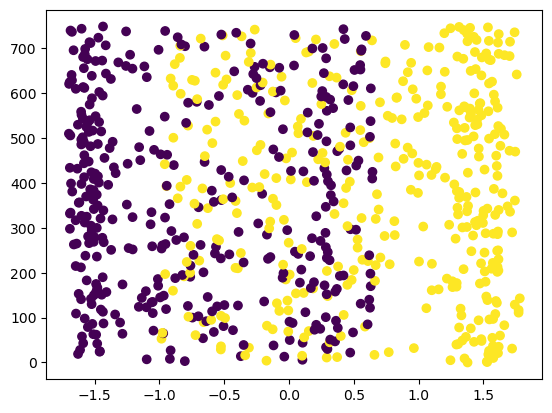

In [38]:
plt.scatter(X_train_isomap[:, 0], range(0, 750), c=y_train)

In [39]:
from sklearn.manifold import TSNE
import umap

In [40]:
%%time
tsne = TSNE(n_components=1, perplexity=50, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.transform(X_test)

CPU times: total: 13.6 s
Wall time: 3.57 s


AttributeError: 'TSNE' object has no attribute 'transform'

In [1]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ tensorflow

Looking in indexes: https://mirror-pypi.runflare.com/simple/
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.6/351.2 MB 8.4 MB/s eta 0:00:42
   ---------------------------------------- 2.9/351.2 MB 7.9 MB/s eta 0:00:45
   ---------------------------------------- 4.2/351.2 MB 6.9 MB/s eta 0:00:50
    --------------------------------------- 5.8/351.2 MB 7.3 MB/s eta 0:00:48
    --------------------------------------- 7.1/351.2 MB 7.0 MB/s eta 0:00:49
   - -------------------------------------- 9.2/351.2 MB 7.6 MB/s eta 0:00:46
   - -------------------------------------- 11.3/351.2 MB 8.0 MB/s eta 0:00:43
   - -------------------------------------- 13.6/351.2 MB 8.5 MB/s eta 0:00:40
   - -------------------------------------- 15.5/351.2 MB 8.5 MB/s eta 0:00:40
   -- ------------------------------------- 18.4/351.2 MB 8.9 MB/s eta 0:00:38
   -- ------------------------------------- 20.7/351.2 MB 9.2 MB/s eta 0:00:36
   --

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [7]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ tensorflow-gpu

Looking in indexes: https://mirror-pypi.runflare.com/simple/
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [77 lines of output]
      Traceback (most recent call last):
        File "C:\Users\USER\AppData\Local\Temp\pip-build-env-5kv5nsrl\overlay\Lib\site-packages\setuptools\_vendor\packaging\requirements.py", line 36, in __init__
          parsed = _parse_requirement(requirement_string)
        File "C:\Users\USER\AppData\Local\Temp\pip-build-env-5kv5nsrl\overlay\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 71, in parse_requirement
          return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
        File "C:\Users\USER\AppData\Local\Temp\pip-build-env-5kv5nsrl\overlay\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 89, in _parse_requirement
          url, specifier, marker = _parse_requirement_details(tokenizer)
                                   ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^
        File "C:\Users\USER

In [ ]:
%pip install tensorflow-directml -i https://pypi.org/simple --trusted-host pypi.org

^C
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-directml (from versions: none)
ERROR: No matching distribution found for tensorflow-directml


In [1]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ tensorflow-datasets

Looking in indexes: https://mirror-pypi.runflare.com/simple/
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.3 MB 2.9 MB/s eta 0:00:02
   ------- -------------------------------- 1.0/5.3 MB 2.7 MB/s eta 0:00:02
   --------- ------------------------------ 1.3/5.3 MB 2.5 MB/s eta 0:00:02
   ------------------- -------------------- 2.6/5.3 MB 3.2 MB/s eta 0:00:01
   --------------------- ------------------ 2.9/5.3 MB 2.9 MB/s eta 0:00:01
   --------------------------- ------------ 3.7/5.3 MB 3.1 MB/s eta 0:00:01
   ----------------------------------- ---- 4.7/5.3 MB 3.4 MB/s eta 0:00:01
   -----

In [2]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.21.0
[]


In [6]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ importlib_resources

Looking in indexes: https://mirror-pypi.runflare.com/simple/
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow_datasets

In [ ]:
(ds_train, ds_test), ds_info = tensorflow_datasets.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]